## Importación de Bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras import models
from keras import layers
from keras.utils import to_categorical
from keras.datasets import reuters

## División de Datos

In [2]:
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Explorando Data

In [3]:
train_data.shape

(8982,)

In [4]:
test_data.shape

(2246,)

In [47]:
word_index = reuters.get_word_index()
word_index=dict([(value, key) for (key, value) in word_index.items()])
for i in train_data[3]:
    print(word_index.get(i-3, "?")) # Si no encuentra la palabra, imprime "?"

?
the
farmers
home
administration
the
u
s
agriculture
department's
farm
lending
arm
could
lose
about
seven
billion
dlrs
in
outstanding
principal
on
its
severely
?
borrowers
or
about
one
fourth
of
its
farm
loan
portfolio
the
general
accounting
office
gao
said
in
remarks
prepared
for
delivery
to
the
senate
agriculture
committee
brian
crowley
senior
associate
director
of
gao
also
said
that
a
preliminary
analysis
of
proposed
changes
in
?
financial
eligibility
standards
indicated
as
many
as
one
half
of
?
borrowers
who
received
new
loans
from
the
agency
in
1986
would
be
?
under
the
proposed
system
the
agency
has
proposed
evaluating
?
credit
using
a
variety
of
financial
ratios
instead
of
relying
solely
on
?
ability
senate
agriculture
committee
chairman
patrick
leahy
d
vt
?
the
proposed
eligibility
changes
telling
?
administrator
?
clark
at
a
hearing
that
they
would
mark
a
dramatic
shift
in
the
agency's
purpose
away
from
being
farmers'
lender
of
last
resort
toward
becoming
a
big
city
bank
but


In [6]:
train_labels[0]

np.int64(3)

## Vectorización de data

In [7]:
def vectorizar_secuencia(secuencia, longitud=10000):
    resultado = np.zeros((len(secuencia), longitud))
    for i, sec in enumerate(secuencia):
        resultado[i, sec] = 1
    return resultado

In [8]:
x_train=vectorizar_secuencia(train_data)
x_test=vectorizar_secuencia(test_data)

In [9]:
x_train.shape

(8982, 10000)

In [10]:
train_labels[2]

np.int64(3)

In [11]:
train_labels.shape

(8982,)

In [ ]:
y_train= to_categorical(train_labels)
y_test= to_categorical(test_labels)

In [ ]:
y_train.shape

(8982, 46)

In [ ]:
y_train[0]

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [15]:
y_test.shape

(2246, 46)

## Creación de Capas 

In [ ]:
model=models.Sequential()
model.add(layers.Dense(64, activation="relu", input_shape=(10000,)))
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dense(46, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compilación del Modelo

In [17]:
model.compile(optimizer="rmsprop", 
               loss="categorical_crossentropy", 
               metrics=["accuracy"])

## Entrenamiento del Modelo

In [18]:
modelo=model.fit(x_train, y_train, epochs=30, batch_size=512, validation_split=0.2)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.4942 - loss: 2.7783 - val_accuracy: 0.5838 - val_loss: 1.9183
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.6703 - loss: 1.5957 - val_accuracy: 0.6923 - val_loss: 1.4334
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7278 - loss: 1.2248 - val_accuracy: 0.7156 - val_loss: 1.2513
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.7787 - loss: 1.0049 - val_accuracy: 0.7396 - val_loss: 1.1667
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8188 - loss: 0.8429 - val_accuracy: 0.7496 - val_loss: 1.0894
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8511 - loss: 0.7150 - val_accuracy: 0.7763 - val_loss: 1.0205
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8781 - loss: 0.6043 - val_accuracy: 0.7869 - val_loss: 0.9926
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.8951 - loss: 0.5147 - val_accuracy: 0.7852 - v

In [ ]:
modelo_dict=modelo.history
print(modelo_dict)

{'accuracy': [0.49422407150268555, 0.6702853441238403, 0.7277661561965942, 0.7787056565284729, 0.8187891244888306, 0.8510786294937134, 0.878079354763031, 0.8950591683387756, 0.9081419706344604, 0.9220598340034485, 0.9331941604614258, 0.9377870559692383, 0.9430758357048035, 0.9501739740371704, 0.9528183937072754, 0.9551844000816345, 0.9575504660606384, 0.9585247039794922, 0.9586638808250427, 0.9607515931129456, 0.9599164724349976, 0.9618650078773499, 0.9632567763328552, 0.9635351300239563, 0.962421715259552, 0.9622825384140015, 0.9622825384140015, 0.9628392457962036, 0.9622825384140015, 0.9639526605606079], 'loss': [2.7782623767852783, 1.5957469940185547, 1.2248141765594482, 1.0048731565475464, 0.842877209186554, 0.7150204181671143, 0.6043107509613037, 0.5146990418434143, 0.4395199418067932, 0.37829679250717163, 0.3284364640712738, 0.28862181305885315, 0.254800021648407, 0.22715802490711212, 0.20311300456523895, 0.19125190377235413, 0.16906985640525818, 0.15654298663139343, 0.1530868858

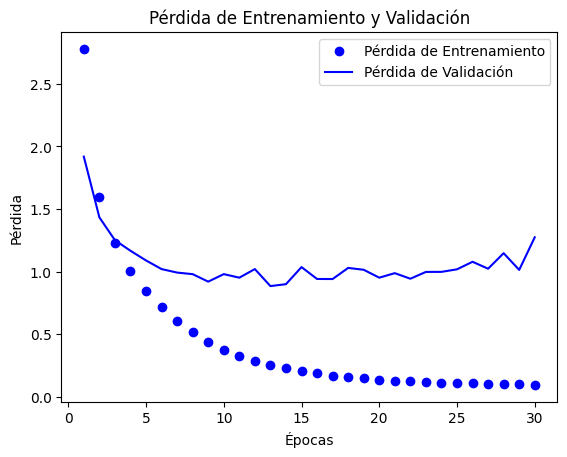

In [20]:
loss_values = modelo_dict['loss']
val_loss_values = modelo_dict['val_loss']
epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'bo', label='Pérdida de Entrenamiento')
plt.plot(epochs, val_loss_values, 'b', label='Pérdida de Validación')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

## Mejoramiento del modelo

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.4832 - loss: 3.1240 - val_accuracy: 0.6288 - val_loss: 2.2158
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.6573 - loss: 1.8855 - val_accuracy: 0.6589 - val_loss: 1.6836
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.7137 - loss: 1.4907 - val_accuracy: 0.6845 - val_loss: 1.5540
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7566 - loss: 1.2968 - val_accuracy: 0.7546 - val_loss: 1.3943
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.7985 - loss: 1.1505 - val_accuracy: 0.7362 - val_loss: 1.3219
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8146 - loss: 1.0353 - val_accuracy: 0.7429 - val_loss: 1.3041
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8386 - loss: 0.9394 - val_accuracy: 0.7540 - val_loss: 1.2282
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8557 - loss: 0.8573 - val_accuracy: 0.7685 - v

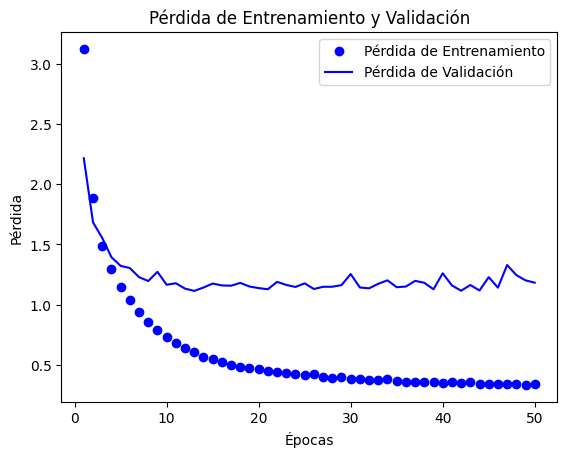

In [21]:
from keras import regularizers


model2=models.Sequential()
model2.add(layers.Dense(64, activation="relu", input_shape=(10000,), kernel_regularizer=regularizers.l2(0.001)))
model2.add(layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)))
model2.add(layers.Dense(46, activation="softmax"))

model2.compile(optimizer="rmsprop", 
               loss="categorical_crossentropy", 
               metrics=["accuracy"])

modelo2=model2.fit(x_train, y_train, epochs=50, batch_size=512, validation_split=0.2)

modelo_dict2=modelo2.history
print(modelo_dict2)

loss_values2 = modelo_dict2['loss']
val_loss_values2 = modelo_dict2['val_loss']
epochs = range(1, len(loss_values2) + 1)

plt.plot(epochs, loss_values2, 'bo', label='Pérdida de Entrenamiento')
plt.plot(epochs, val_loss_values2, 'b', label='Pérdida de Validación')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.3361 - loss: 3.3846 - val_accuracy: 0.5559 - val_loss: 2.4264
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5807 - loss: 2.1937 - val_accuracy: 0.6366 - val_loss: 1.8318
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.6319 - loss: 1.7806 - val_accuracy: 0.6600 - val_loss: 1.6237
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.6690 - loss: 1.5800 - val_accuracy: 0.7006 - val_loss: 1.4880
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6991 - loss: 1.4503 - val_accuracy: 0.7190 - val_loss: 1.4179
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.7268 - loss: 1.3236 - val_accuracy: 0.7307 - val_loss: 1.3534
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7492 - loss: 1.2555 - val_accuracy: 0.7479 - val_loss: 1.3033
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7688 - loss: 1.1679 - val_accuracy: 0.7607 - v

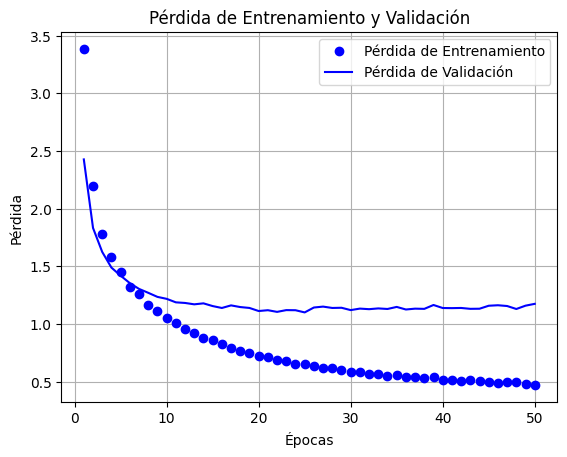

In [22]:
model3=models.Sequential()
model3.add(layers.Dense(64, activation="relu", input_shape=(10000,), kernel_regularizer=regularizers.l2(0.001)))
model3.add(layers.Dropout(0.5))
model3.add(layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)))
model3.add(layers.Dense(46, activation="softmax"))

model3.compile(optimizer="rmsprop", 
               loss="categorical_crossentropy", 
               metrics=["accuracy"])

modelo3=model3.fit(x_train, y_train, epochs=50, batch_size=512, validation_split=0.2)

modelo_dict3=modelo3.history
print(modelo_dict3)

loss_values3 = modelo_dict3['loss']
val_loss_values3 = modelo_dict3['val_loss']
epochs = range(1, len(loss_values3) + 1)

plt.plot(epochs, loss_values3, 'bo', label='Pérdida de Entrenamiento')
plt.plot(epochs, val_loss_values3, 'b', label='Pérdida de Validación')
plt.title('Pérdida de Entrenamiento y Validación')
plt.grid()
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.3459 - loss: 3.4409 - val_accuracy: 0.5008 - val_loss: 2.6333
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5351 - loss: 2.3988 - val_accuracy: 0.6077 - val_loss: 1.9632
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.6060 - loss: 1.9194 - val_accuracy: 0.6733 - val_loss: 1.6926
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6565 - loss: 1.6773 - val_accuracy: 0.7056 - val_loss: 1.5157
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.6868 - loss: 1.5320 - val_accuracy: 0.7140 - val_loss: 1.4329
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7072 - loss: 1.4155 - val_accuracy: 0.7184 - val_loss: 1.3861
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.7317 - loss: 1.3293 - val_accuracy: 0.7351 - val_loss: 1.3424
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7459 - loss: 1.2626 - val_accuracy: 0.7418 - v

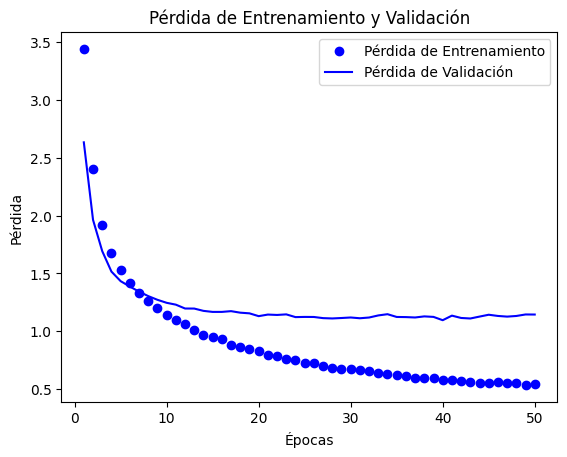

In [23]:
from keras import regularizers


model4=models.Sequential()
model4.add(layers.Dense(50, activation="relu", input_shape=(10000,), kernel_regularizer=regularizers.l2(0.001)))
model4.add(layers.Dropout(0.5))
model4.add(layers.Dense(50, activation="relu", kernel_regularizer=regularizers.l2(0.001)))
model4.add(layers.Dense(46, activation="softmax"))

model4.compile(optimizer="rmsprop", 
               loss="categorical_crossentropy", 
               metrics=["accuracy"])

modelo4=model4.fit(x_train, y_train, epochs=50, batch_size=512, validation_split=0.2)

modelo_dict4=modelo4.history
print(modelo_dict4)

loss_values4 = modelo_dict4['loss']
val_loss_values4 = modelo_dict4['val_loss']
epochs = range(1, len(loss_values4) + 1)

plt.plot(epochs, loss_values4, 'bo', label='Pérdida de Entrenamiento')
plt.plot(epochs, val_loss_values4, 'b', label='Pérdida de Validación')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

/tmp/ipykernel_36367/4188523413.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_loss_values4, 'b', color='red', label='Pérdida de Validación Modelo con RegularizaciónL2 y Dropout')


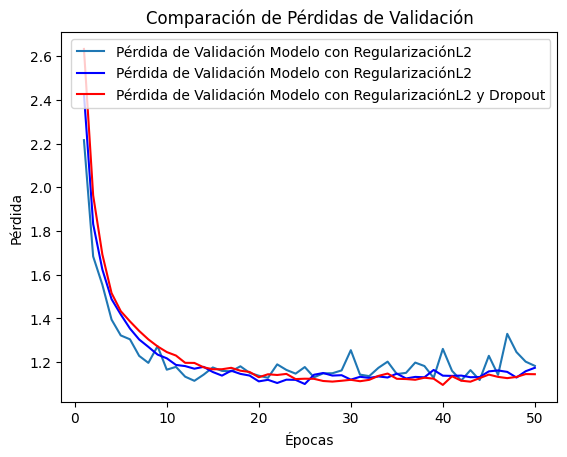

In [24]:
plt.plot(epochs, val_loss_values2, label='Pérdida de Validación Modelo con RegularizaciónL2')
plt.plot(epochs, val_loss_values3, 'b', label='Pérdida de Validación Modelo con RegularizaciónL2')
plt.plot(epochs, val_loss_values4, 'b', color='red', label='Pérdida de Validación Modelo con RegularizaciónL2 y Dropout')
plt.title('Comparación de Pérdidas de Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 0.3933 - loss: 3.3346 - val_accuracy: 0.5665 - val_loss: 2.3850
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.5779 - loss: 2.1569 - val_accuracy: 0.6299 - val_loss: 1.7979
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6358 - loss: 1.7676 - val_accuracy: 0.6800 - val_loss: 1.5987
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.6813 - loss: 1.5609 - val_accuracy: 0.7062 - val_loss: 1.4656
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7147 - loss: 1.4195 - val_accuracy: 0.7123 - val_loss: 1.4167
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.7308 - loss: 1.3058 - val_accuracy: 0.7329 - val_loss: 1.3321
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7524 - loss: 1.2242 - val_accuracy: 0.7468 - val_loss: 1.2915
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.7754 - loss: 1.1448 - val_accuracy: 0.7602 - v

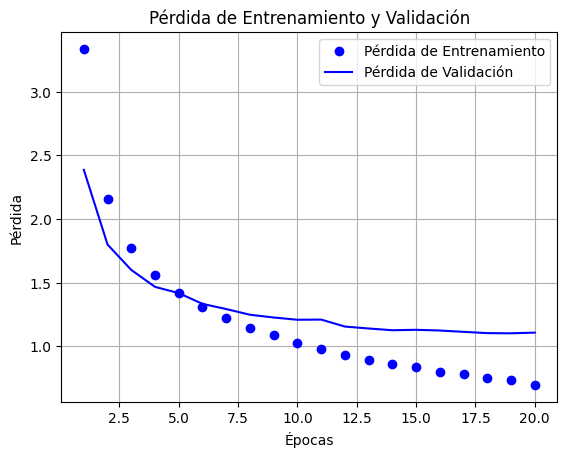

In [25]:
model5=models.Sequential()
model5.add(layers.Dense(64, activation="relu", input_shape=(10000,), kernel_regularizer=regularizers.l2(0.001)))
model5.add(layers.Dropout(0.5))
model5.add(layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)))
model5.add(layers.Dense(46, activation="softmax"))

model5.compile(optimizer="rmsprop", 
               loss="categorical_crossentropy", 
               metrics=["accuracy"])

modelo5=model5.fit(x_train, y_train, epochs=20, batch_size=512, validation_split=0.2)

modelo_dict5=modelo5.history
print(modelo_dict5)

loss_values5 = modelo_dict5['loss']
val_loss_values5 = modelo_dict5['val_loss']
epochs = range(1, len(loss_values5) + 1)

plt.plot(epochs, loss_values5, 'bo', label='Pérdida de Entrenamiento')
plt.plot(epochs, val_loss_values5, 'b', label='Pérdida de Validación')
plt.title('Pérdida de Entrenamiento y Validación')
plt.grid()
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

## Predicciones

In [26]:
Predicciones=model5.predict(x_test)
print(Predicciones[0])
print(np.sum(Predicciones[0]))

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[1.5962121e-05 3.4127461e-05 1.8342176e-05 9.3559158e-01 5.3757921e-02
 6.9797475e-06 4.2506184e-05 1.8283924e-04 1.4487470e-03 9.7562624e-05
 1.1309932e-04 1.2094090e-04 1.4297659e-05 1.1402866e-03 3.1970598e-05
 4.0719868e-05 3.2105036e-03 1.2469295e-03 3.8400572e-06 7.6570330e-05
 7.8960229e-04 8.8316847e-05 6.4558949e-06 7.6487940e-04 3.6519280e-06
 1.2721634e-05 2.3239194e-05 3.9397815e-05 2.6471136e-05 2.4857078e-04
 8.5913343e-05 4.9600214e-05 1.0273527e-05 4.1069892e-05 8.5265900e-05
 3.9173327e-05 1.4344052e-05 1.4140427e-05 1.6779799e-05 1.9458086e-04
 1.3814485e-05 1.7173895e-04 4.9795026e-06 5.8229393e-06 4.8018683e-05
 5.4645348e-06]
1.0000001


In [43]:
predic=np.argmax(Predicciones[0])
print(predic)

3


In [44]:
confianza = np.max(Predicciones[0])
print(confianza)

0.9355916


In [46]:
palabra = word_index[3]
print(palabra)

to
